In [ ]:
#Monday: Dillan Andrews, Alex Velasquez
#Wednesday: Dillan Andrews, Alex Velasquez
#https://www.kaggle.com/datasets/rhythmghai/resume-screening-dataset-200k-candidates

In [ ]:
# Import necessary libraries
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
#Import dataset
df = pd.read_csv('resume_dataset_200k_enhanced.csv')
#shorten the dataset to the first 1000 values
df = df[:1000]
#Get features and target
dftrim = df[['age','cgpa','internships','projects','programming_languages','certifications','experience_years','hackathons','research_papers','skills_score','soft_skills_score','resume_length_words','hired']]
X = df[['age','cgpa','internships','projects','programming_languages','certifications','experience_years','hackathons','research_papers','skills_score','soft_skills_score','resume_length_words']]
Y = df['hired']

In [ ]:
# Print basic information about the dataset
print("=" * 60)
print("INTERVIEWEE DATASET INFORMATION")
print("=" * 60)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

INTERVIEWEE DATASET INFORMATION
Number of samples: 1000
Number of features: 12


In [ ]:
# Split the data into training (60%) and testing (40%) sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=42)

#Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#Run the data through a POLYNOMIAL kernel
svm_poly = SVC(kernel='poly', degree=3, C=3, gamma='scale')
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy: {accuracy_poly * 100:.2f}%")

Accuracy: 61.75%


In [ ]:
#Detailed report for POLYNOMIAL kernel
print(classification_report(y_test, y_pred_poly, zero_division = 0))

              precision    recall  f1-score   support

           0       0.25      0.08      0.13       131
           1       0.66      0.88      0.76       269

    accuracy                           0.62       400
   macro avg       0.46      0.48      0.44       400
weighted avg       0.53      0.62      0.55       400



In [ ]:
#Find the two best features to compare
# See the average difference between the two features
print("Average values per Employment values:")
print(dftrim.groupby('hired').mean().round(1))
print()

Average values per Employment values:
        age  cgpa  internships  projects  programming_languages  \
hired                                                             
0      27.0   7.6          1.5       2.9                    3.0   
1      27.6   7.5          1.5       3.0                    3.0   

       certifications  experience_years  hackathons  research_papers  \
hired                                                                  
0                 0.9               1.3         0.5              0.2   
1                 1.0               1.6         0.5              0.2   

       skills_score  soft_skills_score  resume_length_words  
hired                                                        
0              13.6                6.6                445.6  
1              14.0                6.4                451.3  



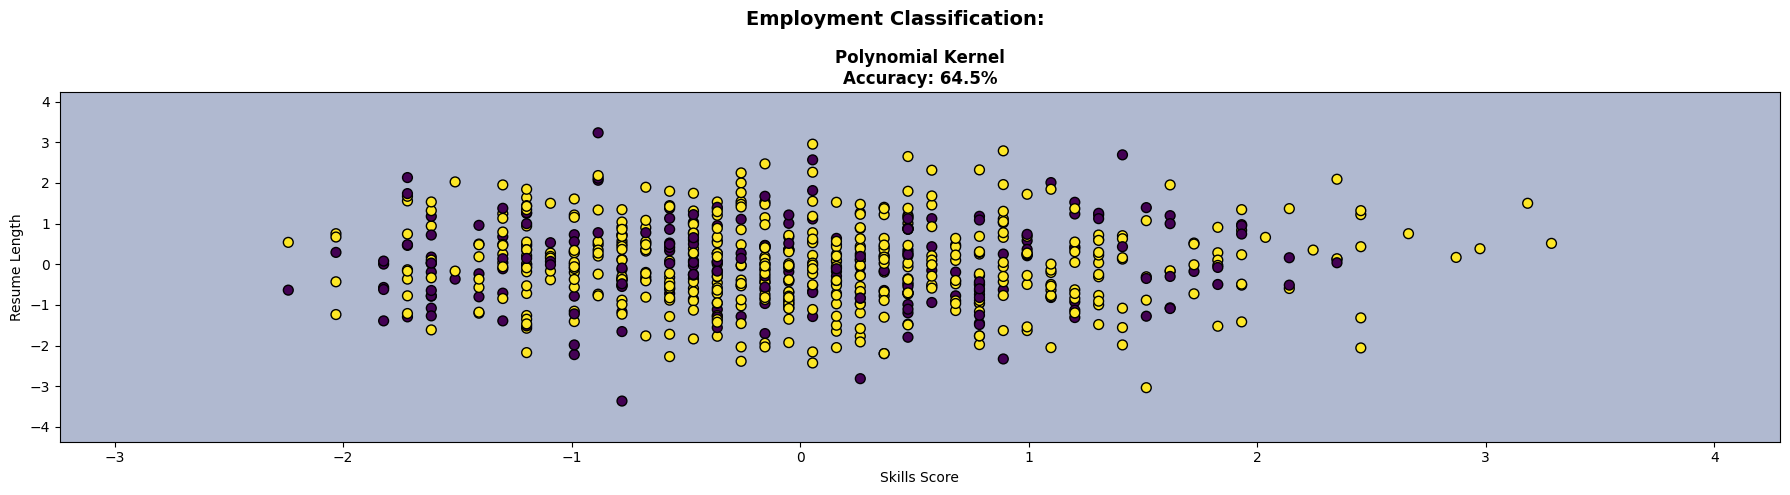

In [ ]:
#Create a Visualization
#Select two features
X_2d = X[['skills_score','resume_length_words']]  # Select first 2 features only
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, Y, test_size=0.3, random_state=42
)

#Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Create a figure
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

kernels = [('poly', 'Polynomial', accuracy_poly)]

# Create mesh grid for plotting decision boundaries
# This creates a grid of points covering the entire plot area
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Plot kernel
for idx, (kernel_name, kernel_label, accuracy) in enumerate(kernels):
    # Train a model with this kernel on 2D data
    if kernel_name == 'poly':
        model = SVC(kernel=kernel_name, degree=3, C=.10, gamma='scale')
    else:
        model = SVC(kernel=kernel_name, C=.10, gamma='scale')

    model.fit(X_train_2d_scaled, y_train_2d)

    # Predict class for every point in the mesh grid
    # This shows us the decision boundaries
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision regions (background colors)
    axes.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    # Plot the actual training data points
    axes.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                     c=y_train_2d, edgecolors='k', cmap='viridis', s=50)

    # Add title and labels
    axes.set_title(f'{kernel_label} Kernel\nAccuracy: {accuracy*100:.1f}%',
                       fontsize=12, fontweight='bold')
    axes.set_xlabel('Skills Score', fontsize=10)
    axes.set_ylabel('Resume Length', fontsize=10)

# Add overall title
plt.suptitle('Employment Classification:',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

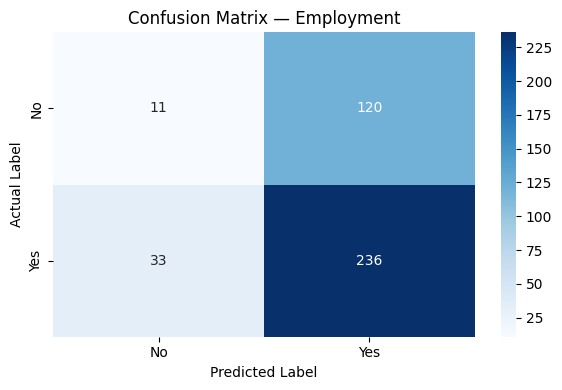

   -> Confusion matrix saved as 'employment.png'



In [ ]:
# --- Confusion Matrix Heatmap ---
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,           # What percentage did we get right?
    classification_report,    # Detailed per-class performance
    confusion_matrix          # Table showing correct vs incorrect predictions
)
# This visual makes it easy to see where the model gets confused
cm = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,                                        # The confusion matrix data
    annot=True,                                # Show numbers inside cells
    fmt='d',                                   # Format as integers (not decimals)
    cmap='Blues',                               # Blue color scheme
    xticklabels=['No', 'Yes'],       # Labels for predicted (x-axis)
    yticklabels=['No', 'Yes']        # Labels for actual (y-axis)
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix — Employment')
plt.tight_layout()
plt.savefig('employment.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'employment.png'")
print()

In [ ]:
#Using the model to predict new data
#Prediction with new interviewee data
#'age','cgpa','internships','projects','programming_languages','certifications','experience_years','hackathons','research_papers','skills_score','soft_skills_score','resume_length_words']]
new_interviewee = pd.DataFrame({
    'age':                    [25],
    'cgpa':                   [8],
    'internships':            [3],
    'projects':               [4],
    'programming_languages':  [2],
    'certifications':         [1],
    'experience_years':       [3],
    'hackathons':             [0],
    'research_papers':        [0],
    'skills_score':           [13],
    'soft_skills_score':      [7],
    'resume_length_words':    [500],
})

print("New Interviewee measurements:")
print(new_interviewee.to_string(index=False))
print()

# Scale the new seed using the SAME scaler from training
# (Never create a new scaler for new data!)
new_interviewee_scaled = scaler.transform(new_interviewee)

# Make a prediction
prediction = svm_poly.predict(new_interviewee_scaled)
print(f"Predicted variety: {prediction[0]}")

New Interviewee measurements:
 age  cgpa  internships  projects  programming_languages  certifications  experience_years  hackathons  research_papers  skills_score  soft_skills_score  resume_length_words
  25     8            3         4                      2               1                 3           0                0            13                  7                  500

Predicted variety: 1


This model above was built on a dataset that collects information on interviewees, and whether they were hired with their current resume. Using the Polynomial Kernal to build a prediction model, we could get a prediction with an accuracy around 60%. Looking into this low accuracy, we used a confusion matrix to see how the model is making its predictions. The confusion matrix shows that this model prefers to make True Positive and False Positive claims. This could be caused by a high amount of positive (hired) results in the data, making the model assume that it can get the best score by always predicting positive.